# <h1 style="text-align: center; font-weight: bolder;">LAB 9</h1>
# <h1 style="text-align: center; font-weight: bold;">TRANSFER LEARNING</h1>


**Goal:** Train a lightweight MLP classifier on top of embeddings extracted from a pretrained audio representation model, using the MagnaTagATune (MTAT) multi-label dataset.

**Key requirements and extras covered**
* Colab/CUDA + Mac MPS + CPU fallback
* End-to-end resource + environmental impact tracking
* Efficient embedding extraction + disk cache
* Clear multi-label metrics: ROC-AUC and PR-AUC
* Audio inspection for documentation (listen + plots)

URL for Google Colab: 

URL for GitHub repo: 

URL for MTAT dataset in GoogleDrive: https://drive.google.com/drive/folders/1urEa6g919ewcRfHIU_RDX4B5yIeuG67C?usp=sharing

# <h2 style="text-align: center; font-weight: bold;">SETUP</h2>

Dependencies are installed and the runtime is configured (device + seeds), alongside experiment config, caching, and tracking (resources + emissions).

# <h3 style="text-align: left; font-weight: bold;">DEPENDENCIES</h3>


In [78]:
!pip -q install torch torchaudio tqdm scikit-learn mirdata omar_rq psutil codecarbon matplotlib ipython

# <h3 style="text-align: left; font-weight: bold;">IMPORTS</h3>


In [79]:
import os
import json
import time
import math
import random
import platform
from pathlib import Path
from dataclasses import dataclass, asdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import torchaudio
import matplotlib.pyplot as plt

from tqdm.auto import tqdm, trange
from torch.utils.data import Dataset, DataLoader

import psutil
from codecarbon import OfflineEmissionsTracker

import mirdata
from omar_rq import get_model

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import roc_auc_score, average_precision_score

from IPython.display import Audio, display

# <h3 style="text-align: left; font-weight: bold;">RUNTIME SETUP</h3>

The best available device is detected (**CUDA**, **MPS**, or **CPU**) and seeds are set for reproducibility.

In [80]:
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = get_device()
print("Device:", device)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(42)

Device: mps


# <h3 style="text-align: left; font-weight: bold;">CONFIG</h3>

Dataset limits, embedding extraction settings, MLP hyperparameters, training settings, and caching paths are defined here.

**PATHS**

MTAT is expected to be stored in a parallel folder (same structure used in previous labs). Common relative locations are tried automatically, and overrides are supported via:

* Environment variable: MTAT_DATA_HOME
* Or a manual edit of data_home

A cache_dir is also defined to store precomputed embeddings for efficiency.

**Google Colab: Mount Drive and set MTAT paths**

When running on Colab, Google Drive is mounted and MTAT_DATA_HOME is pointed to the shared MTAT folder. Cached embeddings are stored in Drive to avoid recomputation after runtime resets.

In [81]:
if "color" not in globals():
    class color:
        PURPLE = '\033[95m'
        CYAN = '\033[96m'
        DARKCYAN = '\033[36m'
        BLUE = '\033[94m'
        GREEN = '\033[92m'
        YELLOW = '\033[93m'
        RED = '\033[91m'
        BOLD = '\033[1m'
        UNDERLINE = '\033[4m'
        END = '\033[0m'

def in_colab():
    try:
        import google.colab  
        return True
    except Exception:
        return False

is_colab = in_colab()

if is_colab:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        print(color.BOLD + "Drive mounted." + color.END)
    except Exception as e:
        print(color.YELLOW + f"[warn] Drive mount failed: {repr(e)}" + color.END)

def resolve_data_home():
    env = os.getenv("MTAT_DATA_HOME", "").strip()
    if env:
        p = Path(env).expanduser().resolve()
        if p.exists():
            return p

    here = Path.cwd().resolve()
    candidates = [
        here / "mirdata",
        here.parent / "mirdata",
        here.parent / "data",
        here.parent / "datasets",
        here.parent / "MTAT",
        here.parent / "magnatagatune",
        here.parent / "mirdata" / "magnatagatune",
        here / "data",
        here / "datasets",
    ]
    for c in candidates:
        if c.exists():
            return c

    return here / "mirdata"

if is_colab:
    drive_candidates = [
        Path("/content/drive/MyDrive/MTAT").resolve(),
        Path("/content/drive/MyDrive/magnatagatune").resolve(),
        Path("/content/drive/MyDrive/datasets/MTAT").resolve(),
        Path("/content/drive/MyDrive/datasets/magnatagatune").resolve(),
    ]
    for p in drive_candidates:
        if p.exists():
            os.environ["MTAT_DATA_HOME"] = str(p)
            print(color.BOLD + "Using MTAT from Drive:" + color.END, p)
            break

data_home = resolve_data_home()

CFG = {
    "mode": "tl",

    # audio
    "sample_rate": 16000,
    "clip_seconds": 2.0,

    # dataset
    "top_k_tags": 50,
    "max_train_items": 8000,
    "max_val_items": 2000,
    "max_test_items": 2000,

    # embedding extraction
    "repr_model_id": "mtg-upf/clap_omarrq_mp_small_music",
    "emb_layers": [6],
    "batch_size": 32,

    # MLP
    "mlp_hidden": 256,
    "mlp_dropout": 0.2,

    # training
    "epochs": 100,
    "lr": 1e-3,
    "weight_decay": 1e-5,

    # early stop
    "early_stop_patience": 3,

    # defaults (overwritten below)
    "num_workers": 0,
    "pin_memory": False,
}

if is_colab:
    CFG["num_workers"] = 0 if device != "cuda" else 2
else:
    CFG["num_workers"] = 0 if str(device) in ["mps", "cpu"] else 2

CFG["pin_memory"] = (str(device) == "cuda")

if is_colab:
    cache_dir = Path("/content/drive/MyDrive/cache_mtat_transfer").resolve()
else:
    cache_dir = Path("./cache_mtat_transfer").resolve()
cache_dir.mkdir(parents=True, exist_ok=True)

print(color.BOLD + "CFG" + color.END)
print(CFG)

print(color.BOLD + "data_home" + color.END, data_home)
print(color.BOLD + "cache_dir" + color.END, cache_dir)

env_mtat = (os.environ.get("MTAT_ROOT") or os.environ.get("MTAT_DATA_HOME") or "").strip()
if env_mtat:
    print(color.BOLD + "MTAT env" + color.END, env_mtat)

CFG
{'mode': 'tl', 'sample_rate': 16000, 'clip_seconds': 2.0, 'top_k_tags': 50, 'max_train_items': 8000, 'max_val_items': 2000, 'max_test_items': 2000, 'repr_model_id': 'mtg-upf/clap_omarrq_mp_small_music', 'emb_layers': [6], 'batch_size': 32, 'mlp_hidden': 256, 'mlp_dropout': 0.2, 'epochs': 100, 'lr': 0.001, 'weight_decay': 1e-05, 'early_stop_patience': 3, 'num_workers': 0, 'pin_memory': False}
data_home /Users/meco/MBP Files/Gits/ml-for-sound-and-music/data
cache_dir /Users/meco/MBP Files/Gits/ml-for-sound-and-music/lab09/cache_mtat_transfer


# <h3 style="text-align: left; font-weight: bold;">RESOURCE + ENVIRONMENTAL IMPACT TRACKING</h3>


Tracking includes:
* CPU / RAM usage (psutil sampling)
* Optional GPU memory (CUDA only)
* CO2 estimate with CodeCarbon (offline tracker)

Tracking runs from the beginning of the experiment and stops at the end.

In [82]:
@dataclass
class ResourceLog:
    timestamps_s: list
    cpu_percent: list
    ram_used_gb: list
    ram_percent: list
    cuda_mem_alloc_gb: list
    cuda_mem_reserved_gb: list

def start_resource_logging(sample_every_s=2.0):
    log = ResourceLog([], [], [], [], [], [])
    start_t = time.time()

    def sample():
        t = time.time() - start_t
        cpu = psutil.cpu_percent(interval=None)
        mem = psutil.virtual_memory()
        ram_used = (mem.total - mem.available) / (1024**3)
        ram_pct = mem.percent

        cuda_alloc = 0.0
        cuda_res = 0.0
        if torch.cuda.is_available():
            cuda_alloc = torch.cuda.memory_allocated() / (1024**3)
            cuda_res = torch.cuda.memory_reserved() / (1024**3)

        log.timestamps_s.append(float(t))
        log.cpu_percent.append(float(cpu))
        log.ram_used_gb.append(float(ram_used))
        log.ram_percent.append(float(ram_pct))
        log.cuda_mem_alloc_gb.append(float(cuda_alloc))
        log.cuda_mem_reserved_gb.append(float(cuda_res))

    return log, sample, sample_every_s

emissions_tracker = OfflineEmissionsTracker(
    project_name="lab9_mtat_transfer",
    output_dir=str(cache_dir),
    country_iso_code=os.getenv("CODECARBON_COUNTRY_ISO_CODE", "ESP"),
    measure_power_secs=15,
    log_level="error",
)

resource_log, resource_sample, resource_period_s = start_resource_logging(sample_every_s=2.0)

print("Starting emissions tracker...")
emissions_tracker.start()
resource_sample()

Starting emissions tracker...


# <h2 style="text-align: center; font-weight: bold;">LOAD MTAT</h2>



MTAT is loaded from local paths if available. This section covers:
* MTAT root folder resolution
* Annotations + clip metadata loading
* Train/val/test split creation
* Quick audio inspection

# <h3 style="text-align: left; font-weight: bold;">Route resolver</h3>


In [83]:
import csv
from dataclasses import dataclass

TOP_K_TAGS = int(CFG.get("top_k_tags", 50))  # from CFG

def _has_mtat_layout(root: Path) -> bool:
    root = Path(root)
    return (
        (root / "annotations_final.csv").is_file()
        and (root / "clip_info_final.csv").is_file()
        and ((root / "audio").is_dir() or (root / "mp3").is_dir())
    )

def _read_csv_dicts(path: Path):
    path = Path(path)
    with open(path, "r", encoding="utf-8", newline="") as f:
        first = f.readline()
    delim = "\t" if ("\t" in first and "," not in first) else ","
    with open(path, "r", encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f, delimiter=delim)
        return list(reader)

def _find_mtat_root():
    env_root = (os.environ.get("MTAT_ROOT") or os.environ.get("MTAT_DATA_HOME") or "").strip()
    anchors = [Path.cwd()]
    if env_root:
        anchors.insert(0, Path(env_root))

    for a in anchors:
        a = Path(a).expanduser().resolve()
        for p in [a] + list(a.parents):
            for cand in [
                p / "data" / "datalabs",
                p / "datalabs",
                p / "data" / "mtat",
                p / "mtat",
                p,
            ]:
                if _has_mtat_layout(cand):
                    return cand

    raise FileNotFoundError(
        "MTAT not found.\n"
        "Expected a folder containing:\n"
        "  annotations_final.csv\n"
        "  clip_info_final.csv\n"
        "  audio/ (or mp3/)\n"
        "Fix: set os.environ['MTAT_ROOT'] to your MTAT root folder."
    )

def _resolve_audio_root(base: Path) -> Path:
    base = Path(base)
    for c in [base / "audio", base / "mp3", base.parent / "audio", base.parent / "mp3"]:
        if c.exists() and c.is_dir():
            return c
    raise FileNotFoundError("audio folder not found near MTAT root")

def _normalize_mp3_rel(mp3_path: str) -> str:
    s = str(mp3_path).strip()
    if s.startswith("audio/"):
        s = s[len("audio/"):]
    if s.startswith("./"):
        s = s[2:]
    return s

def _to01(x):
    try:
        return int(float(str(x).strip()))
    except Exception:
        return 0

def _limit_list(xs, k):
    k = int(k) if k is not None else 0
    if k <= 0:
        return xs
    return xs[: min(len(xs), k)]

base = _find_mtat_root()
ann_path  = base / "annotations_final.csv"
info_path = base / "clip_info_final.csv"
audio_root = _resolve_audio_root(base)

print(color.BOLD + "MTAT root:" + color.END, base)
print("annotations:", ann_path)
print("clip_info:", info_path)
print("audio_root:", audio_root)

ann_rows  = _read_csv_dicts(ann_path)
info_rows = _read_csv_dicts(info_path)

if len(ann_rows) == 0 or len(info_rows) == 0:
    raise ValueError("annotations_final.csv or clip_info_final.csv is empty/unreadable.")

if "clip_id" not in ann_rows[0] or "clip_id" not in info_rows[0]:
    raise ValueError("Expected column 'clip_id' in both annotations_final.csv and clip_info_final.csv")

if "mp3_path" not in info_rows[0]:
    print("clip_info columns:", list(info_rows[0].keys()))
    raise ValueError("Expected column 'mp3_path' in clip_info_final.csv")

tag_cols_all = [c for c in ann_rows[0].keys() if c != "clip_id"]

clip_to_mp3 = {}
for r in info_rows:
    cid = str(r["clip_id"]).strip()
    clip_to_mp3[cid] = _normalize_mp3_rel(r["mp3_path"])

clip_to_y = {}
for r in ann_rows:
    cid = str(r["clip_id"]).strip()
    clip_to_y[cid] = [_to01(r.get(c, 0)) for c in tag_cols_all]

valid_cids = []
for cid, mp3_rel in clip_to_mp3.items():
    if cid not in clip_to_y:
        continue
    fp = audio_root / mp3_rel
    if fp.is_file():
        valid_cids.append(cid)

if len(valid_cids) == 0:
    raise ValueError("No valid clips found (mp3 files missing). Check audio_root and mp3_path normalization.")

Y_full = np.asarray([clip_to_y[cid] for cid in valid_cids], dtype=np.int32)
freq = Y_full.sum(axis=0)
top_idx = np.argsort(freq)[::-1][:TOP_K_TAGS]
tag_cols_top = [tag_cols_all[i] for i in top_idx]

@dataclass
class LocalMTATTrack:
    path: Path
    tags: list

    @property
    def audio(self):
        wav, sr = torchaudio.load(str(self.path))
        if wav.ndim == 2 and wav.shape[0] > 1:
            wav = wav.mean(dim=0, keepdim=True)
        wav = wav.squeeze(0).cpu().numpy()
        return wav, sr

tracks = {}
for cid in valid_cids:
    mp3_rel = clip_to_mp3[cid]
    fp = audio_root / mp3_rel
    y = np.asarray(clip_to_y[cid], dtype=np.int32)[top_idx]
    tags = [t for t, v in zip(tag_cols_top, y) if v == 1]
    tracks[cid] = LocalMTATTrack(path=fp, tags=tags)

track_ids = list(tracks.keys())
print(color.BOLD + "Total valid tracks:" + color.END, len(track_ids))
print("Top tags sample:", tag_cols_top[:15])

seed_everything(42)
random.shuffle(track_ids)

n = len(track_ids)
train_ids = track_ids[: int(0.8 * n)]
val_ids   = track_ids[int(0.8 * n): int(0.9 * n)]
test_ids  = track_ids[int(0.9 * n):]

train_ids = _limit_list(train_ids, CFG.get("max_train_items", 0))
val_ids   = _limit_list(val_ids,   CFG.get("max_val_items", 0))
test_ids  = _limit_list(test_ids,  CFG.get("max_test_items", 0))

print(color.BOLD + "Final split sizes (after limits)" + color.END)
print("train:", len(train_ids), "| val:", len(val_ids), "| test:", len(test_ids))

len(train_ids), len(val_ids), len(test_ids)

MTAT root: /Users/meco/MBP Files/Gits/ml-for-sound-and-music/datalabs
annotations: /Users/meco/MBP Files/Gits/ml-for-sound-and-music/datalabs/annotations_final.csv
clip_info: /Users/meco/MBP Files/Gits/ml-for-sound-and-music/datalabs/clip_info_final.csv
audio_root: /Users/meco/MBP Files/Gits/ml-for-sound-and-music/datalabs/audio
Total valid tracks: 25863
Top tags sample: ['guitar', 'classical', 'slow', 'techno', 'strings', 'drums', 'electronic', 'rock', 'fast', 'piano', 'ambient', 'beat', 'violin', 'vocal', 'synth']
Final split sizes (after limits)
train: 8000 | val: 2000 | test: 2000


(8000, 2000, 2000)

# <h4 style="text-align: left; font-weight: bold;">QUICK AUDIO INSPECTION</h4>

A few random samples are displayed to verify audio loading and tags, and to include audio/plots in the report.

TID: 22197 | #tags: 3 | tags example: ['guitar', 'flute', 'no voice']


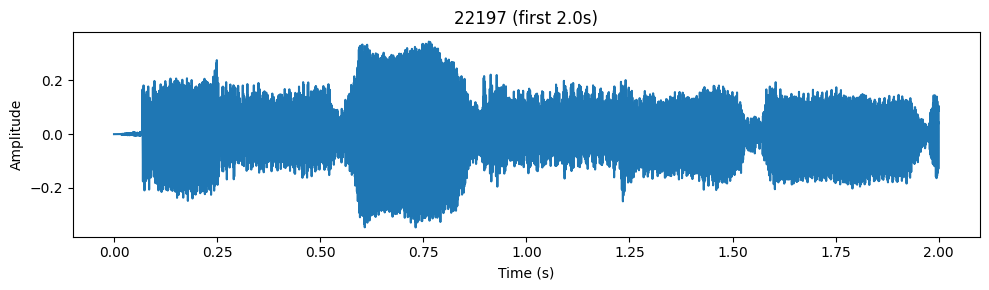

TID: 25929 | #tags: 3 | tags example: ['female', 'woman', 'female voice']


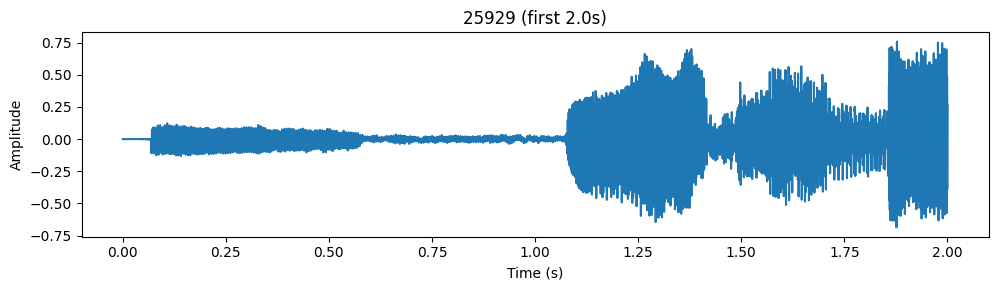

TID: 49176 | #tags: 2 | tags example: ['techno', 'electronic']


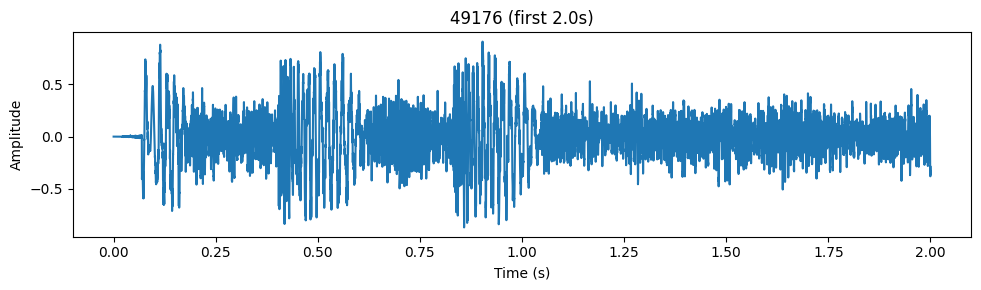

In [84]:

SR = int(CFG.get("sample_rate", 16000))
CLIP_S = float(CFG.get("clip_seconds", 2.0))
INSPECT_S = float(min(3.0, CLIP_S))

def load_track_audio(track_obj, target_sr=None, mono=True):
    """
    Robust loader:
    1) try track_obj.audio
    2) if it fails and track_obj has .path, try torchaudio.load(path)
    3) if torchaudio fails, try ffmpeg decode
    4) if everything fails, return short silence (will be padded later)
    """
    import subprocess, shutil

    if target_sr is None:
        target_sr = SR

    def _ffmpeg_decode_to_float32_mono(path, sr_out):
        ff = shutil.which("ffmpeg")
        if ff is None:
            raise RuntimeError("ffmpeg not found in PATH (needed as fallback).")
        cmd = [
            ff, "-nostdin", "-v", "error",
            "-i", str(path),
            "-ac", "1",
            "-ar", str(int(sr_out)),
            "-f", "f32le",
            "pipe:1",
        ]
        raw = subprocess.check_output(cmd, stderr=subprocess.STDOUT)
        y = np.frombuffer(raw, dtype=np.float32)
        if y.size == 0:
            raise RuntimeError(f"ffmpeg decoded empty audio: {path}")
        return torch.from_numpy(y), int(sr_out)

    try:
        wav, sr = track_obj.audio
        wav = torch.tensor(wav).float()
        if wav.ndim > 1 and mono:
            wav = wav.mean(dim=0)
        if sr != target_sr:
            wav = torchaudio.functional.resample(wav, sr, target_sr)
            sr = target_sr
        return wav, sr

    except Exception as e1:
        path = getattr(track_obj, "path", None)

        if "BAD_AUDIO_COUNT" not in globals():
            globals()["BAD_AUDIO_COUNT"] = 0
        if globals()["BAD_AUDIO_COUNT"] < 5:
            print(f"[warn] audio load failed via track_obj.audio: {repr(e1)}")
            if path is not None:
                print(f"[warn] trying fallbacks for: {path}")
        globals()["BAD_AUDIO_COUNT"] += 1

        if path is not None:
            try:
                w, sr = torchaudio.load(str(path))
                if w.ndim == 2 and mono:
                    w = w.mean(dim=0)
                else:
                    w = w.squeeze(0)
                w = w.float()
                if sr != target_sr:
                    w = torchaudio.functional.resample(w, sr, target_sr)
                    sr = target_sr
                return w, sr
            except Exception:
                pass

            try:
                w, sr = _ffmpeg_decode_to_float32_mono(path, target_sr)
                if w.ndim > 1 and mono:
                    w = w.mean(dim=0)
                return w.float(), sr
            except Exception:
                pass

        sr = int(target_sr)
        w = torch.zeros(int(sr * 1.0), dtype=torch.float32)
        return w, sr

def plot_waveform(wav, sr, title="waveform", max_s=3.0):
    wav = wav.detach().cpu()
    n = min(int(sr * max_s), wav.numel())
    x = np.arange(n) / sr
    plt.figure(figsize=(10, 3))
    plt.plot(x, wav[:n].numpy())
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

for tid in random.sample(train_ids, k=min(3, len(train_ids))):
    t = tracks[tid]
    tags = list(getattr(t, "tags", []) or [])
    wav, sr = load_track_audio(t, target_sr=SR)
    print("TID:", tid, "| #tags:", len(tags), "| tags example:", tags[:10])
    plot_waveform(wav, sr, title=f"{tid} (first {INSPECT_S:.1f}s)", max_s=INSPECT_S)
    n = int(sr * INSPECT_S)
    display(Audio(wav[:n].detach().cpu().numpy(), rate=sr))

resource_sample()

# <h4 style="text-align: left; font-weight: bold;">DATASET DEFINITIONS</h4>

MTAT is multilabel: each track contains a list of tags.  
Tag lists are converted to multi-hot vectors using MultiLabelBinarizer.

In [85]:
if "tracks" not in globals() or "train_ids" not in globals() or "val_ids" not in globals() or "test_ids" not in globals():
    import csv
    from dataclasses import dataclass

    TOP_K_TAGS = 50

    def _has_mtat_layout(root: Path) -> bool:
        root = Path(root)
        return (
            (root / "annotations_final.csv").is_file()
            and (root / "clip_info_final.csv").is_file()
            and ((root / "audio").is_dir() or (root / "mp3").is_dir())
        )

    def _read_csv_dicts(path: Path):
        path = Path(path)
        with open(path, "r", encoding="utf-8", newline="") as f:
            first = f.readline()
        delim = "\t" if ("\t" in first and "," not in first) else ","
        with open(path, "r", encoding="utf-8", newline="") as f:
            reader = csv.DictReader(f, delimiter=delim)
            return list(reader)

    def find_datalabs_root():
        env_root = os.environ.get("MTAT_ROOT") or os.environ.get("MTAT_DATA_HOME")
        anchors = [Path.cwd()]
        if env_root:
            anchors.insert(0, Path(env_root))

        for a in anchors:
            a = Path(a).expanduser().resolve()
            for p in [a] + list(a.parents):
                candidates = [
                    p / "data" / "datalabs",
                    p / "datalabs",
                    p / "data" / "mtat",
                    p / "mtat",
                    p,
                ]
                for cand in candidates:
                    if _has_mtat_layout(cand):
                        return cand

        raise FileNotFoundError(
            "MTAT not found. Expected a folder containing:\n"
            "  annotations_final.csv\n"
            "  clip_info_final.csv\n"
            "  audio/ (or mp3/)\n"
            "Tip para que corra bien: set env MTAT_ROOT or MTAT_DATA_HOME to the MTAT root folder."
        )

    def resolve_audio_root(base: Path) -> Path:
        base = Path(base)
        candidates = [
            base / "audio",
            base / "mp3",
            base.parent / "audio",
            base.parent / "mp3",
        ]
        for c in candidates:
            if c.exists() and c.is_dir():
                return c
        raise FileNotFoundError("audio folder not found near MTAT root")

    def normalize_mp3_rel(mp3_path: str) -> str:
        s = str(mp3_path).strip()
        if s.startswith("audio/"):
            s = s[len("audio/"):]
        if s.startswith("./"):
            s = s[2:]
        return s

    base = find_datalabs_root()
    ann_path = base / "annotations_final.csv"
    info_path = base / "clip_info_final.csv"
    audio_root = resolve_audio_root(base)

    print("[fallback] MTAT root:", base)
    print("[fallback] annotations:", ann_path)
    print("[fallback] clip_info:", info_path)
    print("[fallback] audio_root:", audio_root)

    ann_rows = _read_csv_dicts(ann_path)
    info_rows = _read_csv_dicts(info_path)

    if len(ann_rows) == 0 or len(info_rows) == 0:
        raise ValueError("annotations_final.csv or clip_info_final.csv is empty/unreadable.")

    if "clip_id" not in ann_rows[0] or "clip_id" not in info_rows[0]:
        raise ValueError("Expected column 'clip_id' in both annotations_final.csv and clip_info_final.csv")

    if "mp3_path" not in info_rows[0]:
        print("clip_info columns:", list(info_rows[0].keys()))
        raise ValueError("Expected column 'mp3_path' in clip_info_final.csv")

    tag_cols_all = [c for c in ann_rows[0].keys() if c != "clip_id"]

    def to01(x):
        try:
            return int(float(str(x).strip()))
        except Exception:
            return 0

    clip_to_mp3 = {}
    for r in info_rows:
        cid = str(r["clip_id"]).strip()
        clip_to_mp3[cid] = normalize_mp3_rel(r["mp3_path"])

    clip_to_y = {}
    for r in ann_rows:
        cid = str(r["clip_id"]).strip()
        y = [to01(r.get(c, 0)) for c in tag_cols_all]
        clip_to_y[cid] = y

    valid = []
    for cid, mp3_rel in clip_to_mp3.items():
        if cid not in clip_to_y:
            continue
        fp = audio_root / mp3_rel
        if fp.is_file():
            valid.append(cid)

    if len(valid) == 0:
        raise ValueError("No valid clips found (mp3 files missing). Check audio_root and mp3_path normalization.")

    Y_full = np.asarray([clip_to_y[cid] for cid in valid], dtype=np.int32)
    freq = Y_full.sum(axis=0)
    top_idx = np.argsort(freq)[::-1][:TOP_K_TAGS]
    tag_cols_top = [tag_cols_all[i] for i in top_idx]

    @dataclass
    class LocalMTATTrack:
        path: Path
        tags: list

        @property
        def audio(self):
            wav, sr = torchaudio.load(str(self.path))
            if wav.ndim == 2 and wav.shape[0] > 1:
                wav = wav.mean(dim=0, keepdim=True)
            wav = wav.squeeze(0).cpu().numpy()
            return wav, sr

    tracks = {}
    for cid in valid:
        mp3_rel = clip_to_mp3[cid]
        fp = audio_root / mp3_rel
        y = np.asarray(clip_to_y[cid], dtype=np.int32)[top_idx]
        tags = [t for t, v in zip(tag_cols_top, y) if v == 1]
        tracks[cid] = LocalMTATTrack(path=fp, tags=tags)

    track_ids = list(tracks.keys())
    print("[fallback] Total valid tracks:", len(track_ids))
    print("[fallback] Using top tags:", tag_cols_top[:10], "...")

    seed_everything(42)
    random.shuffle(track_ids)

    n = len(track_ids)
    train_ids = track_ids[: int(0.8 * n)]
    val_ids   = track_ids[int(0.8 * n): int(0.9 * n)]
    test_ids  = track_ids[int(0.9 * n):]

    print("[fallback] splits:", len(train_ids), len(val_ids), len(test_ids))



SR = int(CFG.get("sample_rate", 16000))
CLIP_S = float(CFG.get("clip_seconds", 2.0))

class MTATAudioDataset(Dataset):
    def __init__(self, tracks_dict, track_ids, device, sample_rate=None, audio_duration=None, mlb=None):
        self.tracks = tracks_dict
        self.track_ids = track_ids
        # se deja por compatibilidad, pero NO se usa en __getitem__
        self.device = device  
        self.sample_rate = int(SR if sample_rate is None else sample_rate)
        self.audio_duration = float(CLIP_S if audio_duration is None else audio_duration)
        self.n_samples = int(self.sample_rate * self.audio_duration)

        tag_lists = []
        for tid in self.track_ids:
            tags = list(getattr(self.tracks[tid], "tags", []) or [])
            tag_lists.append(tags)

        if mlb is None:
            self.mlb = MultiLabelBinarizer()
            self.Y = self.mlb.fit_transform(tag_lists).astype(np.float32)
        else:
            self.mlb = mlb
            self.Y = self.mlb.transform(tag_lists).astype(np.float32)

    def __len__(self):
        return len(self.track_ids)

    def __getitem__(self, idx):
        tid = self.track_ids[idx]
        t = self.tracks[tid]

        wav, sr = load_track_audio(t, target_sr=self.sample_rate, mono=True)

        if wav.numel() < self.n_samples:
            wav = F.pad(wav, (0, self.n_samples - wav.numel()))
            start = 0
        else:
            start = random.randint(0, wav.numel() - self.n_samples)

        # IMPORTANTE: el Dataset devuelve CPU. Se mueve a device en los loops (embeddings / training).
        x = wav[start:start + self.n_samples].float().cpu()
        y = torch.tensor(self.Y[idx]).float().cpu()

        return {"audio": x, "labels": y, "tid": tid}

train_audio = MTATAudioDataset(tracks, train_ids, device=device, sample_rate=SR, audio_duration=CLIP_S, mlb=None)
val_audio   = MTATAudioDataset(tracks, val_ids, device=device, sample_rate=SR, audio_duration=CLIP_S, mlb=train_audio.mlb)
test_audio  = MTATAudioDataset(tracks, test_ids, device=device, sample_rate=SR, audio_duration=CLIP_S, mlb=train_audio.mlb)

n_classes = len(train_audio.mlb.classes_)
print("n_classes:", n_classes)
print("Example classes:", train_audio.mlb.classes_[:20])

resource_sample()

n_classes: 50
Example classes: ['ambient' 'beat' 'beats' 'cello' 'choir' 'choral' 'classic' 'classical'
 'country' 'dance' 'drums' 'electronic' 'fast' 'female' 'female vocal'
 'female voice' 'flute' 'guitar' 'harp' 'harpsichord']



# <h3 style="text-align: left; font-weight: bold;">EMBEDDING EXTRACTION</h3>

Embeddings are extracted using a pretrained representation model (OMAR-RQ) and cached to disk:
* If cached embeddings exist, they are loaded instantly.
* Otherwise, embeddings are computed in batches and saved.

This keeps the notebook efficient and repeatable (technically scalable and fast).

In [86]:
MODEL_ID = str(CFG.get("repr_model_id", "mtg-upf/clap_omarrq_mp_small_music"))
LAYERS   = list(CFG.get("emb_layers", [6]))
BS_EMB   = int(CFG.get("batch_size", 32))

# ANTES (para referencia) 
"""
# dentro del for batch...
audio = batch["audio"]
y = batch["labels"].detach().cpu()
tids = list(batch["tid"])

if audio.ndim == 2:
    audio = audio.unsqueeze(1)

audio = audio.to(device, non_blocking=True).float()
B = int(audio.shape[0])

emb_raw = rep.extract_embeddings(audio, layers=layers)

try:
    emb = _as_BD(emb_raw, B).detach().cpu()
except Exception:
    rows = []
    for i in range(B):
        e_i = rep.extract_embeddings(audio[i:i+1], layers=layers)
        rows.append(_as_BD(e_i, 1).detach().cpu())
    emb = torch.cat(rows, dim=0)
"""

# (corregido) 
def _safe_tag(s: str) -> str:
    return "".join([c if (c.isalnum() or c in ["-", "_"]) else "_" for c in str(s)])

def get_cache_paths(split_name: str, model_id: str, layers: list, sr: int, clip_s: float):
    layers_tag = "_".join(map(str, layers))
    mid = _safe_tag(model_id)
    emb_path = cache_dir / f"emb_{split_name}_{mid}_sr{sr}_cs{clip_s}_layers{layers_tag}.pt"
    y_path   = cache_dir / f"y_{split_name}_{mid}_sr{sr}_cs{clip_s}_layers{layers_tag}.pt"
    tid_path = cache_dir / f"tid_{split_name}_{mid}_sr{sr}_cs{clip_s}_layers{layers_tag}.json"
    return emb_path, y_path, tid_path

def _last_tensor(x):
    # omar_rq a veces devuelve lista/tupla por layers
    if isinstance(x, (list, tuple)):
        return x[-1]
    return x

def _as_BD(emb, B: int) -> torch.Tensor:
    """
    Convert OMAR-RQ embeddings to (B, D).

    Handles common shapes:
    * (B, D)
    * (B, T, D) or (T, B, D)
    * (1, B, T, D) or (L, B, T, D) : my case
    * any ndim>=3 where one axis == B
    """
    if isinstance(emb, (list, tuple)):
        emb = emb[-1]
    if not isinstance(emb, torch.Tensor):
        raise TypeError(f"Expected torch.Tensor, got {type(emb)}")

    # 2D: already (B,D) or transposed
    if emb.ndim == 2:
        if emb.shape[0] == B:
            return emb
        if emb.shape[1] == B:
            return emb.t()
        raise RuntimeError(f"2D emb but no dim matches batch B={B}: shape={tuple(emb.shape)}")

    # ndim >= 3: locate batch axis, move it to front, then pool everything except last dim
    if emb.ndim >= 3:
        if B not in emb.shape:
            raise RuntimeError(f"{emb.ndim}D emb but no dim matches batch B={B}: shape={tuple(emb.shape)}")

        # pick first axis that matches B
        b_axis = [i for i, s in enumerate(emb.shape) if s == B][0]
        if b_axis != 0:
            perm = [b_axis] + [i for i in range(emb.ndim) if i != b_axis]
            emb = emb.permute(*perm)  # (B, ...)

        # now emb is (B, d1, d2, ..., D?) and we want (B, D)
        # assumes embedding dim is last axis... pool over middle axes
        if emb.ndim == 3:
            # (B, T, D) or (B, D, T) isn't expected after permute but keep robust
            # decide which axis is D by taking the largest of the last two dims
            if emb.shape[2] >= emb.shape[1]:
                return emb.mean(dim=1)  # (B, D)
            else:
                return emb.mean(dim=2)  # (B, D)

        # ndim >= 4 (e.g., (B, 1, 25, 512)): mean over axes 1..ndim-2 => (B, 512)
        reduce_dims = list(range(1, emb.ndim - 1))
        if len(reduce_dims) > 0:
            emb = emb.mean(dim=reduce_dims)

        if emb.ndim == 1:
            emb = emb.unsqueeze(1)
        if emb.ndim != 2:
            emb = emb.view(emb.shape[0], -1)

        if emb.shape[0] != B:
            raise RuntimeError(f"After pooling, batch mismatch: got {tuple(emb.shape)}, expected B={B}")
        return emb

    raise RuntimeError(f"Unsupported emb shape for B={B}: shape={tuple(emb.shape)}")

@torch.no_grad()
def compute_or_load_embeddings(
    split_name,
    audio_dataset,
    model_id=None,
    layers=None,
    batch_size=None,
):
    model_id = MODEL_ID if model_id is None else str(model_id)
    layers = LAYERS if layers is None else list(layers)
    batch_size = BS_EMB if batch_size is None else int(batch_size)

    sr = int(CFG.get("sample_rate", 16000))
    clip_s = float(CFG.get("clip_seconds", 2.0))

    emb_path, y_path, tid_path = get_cache_paths(split_name, model_id, layers, sr, clip_s)
    expected_n = len(audio_dataset)

    if emb_path.exists() and y_path.exists() and tid_path.exists():
        print(color.BOLD + f"[cache] Loading {split_name} embeddings from disk..." + color.END)
        X = torch.load(emb_path, map_location="cpu")
        Y = torch.load(y_path, map_location="cpu")
        tids = json.loads(tid_path.read_text(encoding="utf-8"))

        ok = (
            isinstance(X, torch.Tensor) and isinstance(Y, torch.Tensor)
            and X.ndim == 2 and Y.ndim == 2
            and X.shape[0] == expected_n and Y.shape[0] == expected_n
            and len(tids) == expected_n
        )
        if ok:
            return X, Y, tids

        print(color.YELLOW + f"[warn] cache mismatch for {split_name} -> recompute and overwrite" + color.END)
        for p in [emb_path, y_path, tid_path]:
            try:
                p.unlink()
            except Exception:
                pass

    print(color.BOLD + f"[compute] Extracting {split_name} embeddings..." + color.END)
    rep = get_model(model_id=model_id, device=device)
    rep.eval()

    loader = DataLoader(
        audio_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=int(CFG.get("num_workers", 0)),
        pin_memory=bool(CFG.get("pin_memory", False)),
    )

    X_list, Y_list, T_list = [], [], []
    target_D = None

    if "EMB_WARN_COUNT" not in globals():
        globals()["EMB_WARN_COUNT"] = 0

    for batch in tqdm(loader, desc=f"Embeddings {split_name}"):
        audio = batch["audio"]
        y = batch["labels"].detach().cpu()
        tids = list(batch["tid"])

        # =========== IMPORTANT: OMAR-RQ expects (B, T), no channel dim
        if audio.ndim == 3 and audio.shape[1] == 1:
            audio = audio.squeeze(1)  # (B,1,T) -> (B,T)
        elif audio.ndim > 2:
            audio = audio.reshape(audio.shape[0], -1)

        audio = audio.to(device, non_blocking=True).float()
        B = int(audio.shape[0])

        emb_raw = rep.extract_embeddings(audio, layers=layers)
        emb_t = _last_tensor(emb_raw)

        # CASE A: model collapses the batch and returns (1, D) even when B>1
        if isinstance(emb_t, torch.Tensor) and emb_t.ndim == 2 and emb_t.shape[0] == 1 and B > 1:
            if globals()["EMB_WARN_COUNT"] < 5:
                print(color.YELLOW + f"[warn] pooled batch embedding {tuple(emb_t.shape)} for B={B} -> per-sample fallback" + color.END)
            globals()["EMB_WARN_COUNT"] += 1

            rows = []
            for i in range(B):
                e_i = rep.extract_embeddings(audio[i:i+1], layers=layers)
                rows.append(_as_BD(e_i, 1).detach().cpu())
            emb = torch.cat(rows, dim=0)

        else:
            try:
                emb = _as_BD(emb_raw, B).detach().cpu()
            except Exception as e:
                if globals()["EMB_WARN_COUNT"] < 5:
                    print(color.YELLOW + f"[warn] batch emb shape issue -> per-sample fallback | {repr(e)}" + color.END)
                    if isinstance(emb_t, torch.Tensor):
                        print(color.YELLOW + f"       emb_last shape: {tuple(emb_t.shape)} | B={B}" + color.END)
                globals()["EMB_WARN_COUNT"] += 1

                rows = []
                for i in range(B):
                    e_i = rep.extract_embeddings(audio[i:i+1], layers=layers)
                    rows.append(_as_BD(e_i, 1).detach().cpu())
                emb = torch.cat(rows, dim=0)

        # enforce consistent D
        if target_D is None:
            target_D = int(emb.shape[1])
        else:
            if int(emb.shape[1]) != target_D:
                if emb.shape[1] > target_D:
                    emb = emb[:, :target_D]
                else:
                    pad = target_D - emb.shape[1]
                    emb = torch.cat([emb, torch.zeros((emb.shape[0], pad), dtype=emb.dtype)], dim=1)

        X_list.append(emb)
        Y_list.append(y)
        T_list.extend(tids)

        if random.random() < 0.05:
            resource_sample()

    X = torch.cat(X_list, dim=0)
    Y = torch.cat(Y_list, dim=0)

    if not (X.shape[0] == Y.shape[0] == len(T_list) == expected_n):
        raise RuntimeError(
            f"Alignment error in {split_name}: "
            f"X0={X.shape[0]} Y0={Y.shape[0]} tids={len(T_list)} expected={expected_n}"
        )

    torch.save(X, emb_path)
    torch.save(Y, y_path)
    tid_path.write_text(json.dumps(T_list, ensure_ascii=False, indent=2), encoding="utf-8")

    print(color.BOLD + f"[saved] {split_name}: X={tuple(X.shape)} Y={tuple(Y.shape)}" + color.END)
    return X, Y, T_list


# run
X_train, Y_train, tids_train = compute_or_load_embeddings("train", train_audio)
X_val,   Y_val,   tids_val   = compute_or_load_embeddings("val",   val_audio)
X_test,  Y_test,  tids_test  = compute_or_load_embeddings("test",  test_audio)

print(color.BOLD + "Embeddings shapes" + color.END)
print("Train:", X_train.shape, Y_train.shape)
print("Val:  ", X_val.shape, Y_val.shape)
print("Test: ", X_test.shape, Y_test.shape)

resource_sample()

[cache] Loading train embeddings from disk...
[cache] Loading val embeddings from disk...
[cache] Loading test embeddings from disk...
Embeddings shapes
Train: torch.Size([8000, 512]) torch.Size([8000, 50])
Val:   torch.Size([2000, 512]) torch.Size([2000, 50])
Test:  torch.Size([2000, 512]) torch.Size([2000, 50])


# <h3 style="text-align: left; font-weight: bold;">MLP CLASSIFIER</h3>

An MLP is trained on top of cached embeddings.  
Because MTAT is multilabel, the setup uses:
* BCEWithLogitsLoss: stable sigmoid + BCE combined
* Sigmoid at inference time

In [87]:
class EmbeddingDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X.float()
        self.Y = Y.float()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return {"embeddings": self.X[idx], "labels": self.Y[idx]}

train_ds = EmbeddingDataset(X_train, Y_train)
val_ds   = EmbeddingDataset(X_val,   Y_val)
test_ds  = EmbeddingDataset(X_test,  Y_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)

class MLP(nn.Module):
    def __init__(self, input_size, hidden=256, output_size=50, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, output_size),
        )

    def forward(self, x):
        return self.net(x)

input_dim = X_train.shape[1]
model = MLP(input_size=input_dim, hidden=256, output_size=n_classes, dropout=0.2).to(device)

loss_fn = nn.BCEWithLogitsLoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

print(model)
print("Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

resource_sample()

MLP(
  (net): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=50, bias=True)
  )
)
Trainable params: 144178


In [88]:
# checkpoints: save best model + resume support
def save_checkpoint(path, model, optimizer, epoch, history, extra=None):
    payload = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optim_state": optimizer.state_dict(),
        "history": history,
        "extra": extra or {},
    }
    torch.save(payload, path)

def load_checkpoint(path, model, optimizer=None):
    ckpt = torch.load(path, map_location="cpu")
    model.load_state_dict(ckpt["model_state"])
    if optimizer is not None and "optim_state" in ckpt:
        optimizer.load_state_dict(ckpt["optim_state"])
    return ckpt

best_model_path = cache_dir / "best_model.pt"
last_ckpt_path  = cache_dir / "last_checkpoint.pt"

# <h3 style="text-align: left; font-weight: bold;">TRAINLOOP</h3>

Training is run for a configured number of epochs while tracking:
* Train/val loss
* Validation ROC-AUC / PR-AUC every few epochs (kept efficient)

Also included:
* To be able to resume from the last checkpoint if available
* best_model.pt: saved based on validation PR-AUC (micro!)

In [89]:
from tqdm.auto import tqdm  

@torch.no_grad()
def predict_probs(model, loader, desc="Predict", show_pbar=True):
    model.eval()
    ys, ps = [], []
    it = tqdm(loader, desc=desc, leave=False) if show_pbar else loader
    for batch in it:
        x = batch["embeddings"].to(device)
        y = batch["labels"].cpu().numpy()
        logits = model(x)
        p = torch.sigmoid(logits).detach().cpu().numpy()
        ys.append(y)
        ps.append(p)
    return np.vstack(ys), np.vstack(ps)

def train_one_epoch(model, loader, desc="Train", show_pbar=True):
    model.train()
    total = 0.0
    it = tqdm(loader, desc=desc, leave=False) if show_pbar else loader
    for batch in it:
        x = batch["embeddings"].to(device)
        y = batch["labels"].to(device)

        logits = model(x)
        loss = loss_fn(logits, y)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total += float(loss.item())

        # mostrar loss en la barra
        if show_pbar:
            it.set_postfix(loss=f"{loss.item():.4f}")

    return total / max(1, len(loader))

@torch.no_grad()
def eval_loss(model, loader, desc="Val loss", show_pbar=True):
    model.eval()
    total = 0.0
    it = tqdm(loader, desc=desc, leave=False) if show_pbar else loader
    for batch in it:
        x = batch["embeddings"].to(device)
        y = batch["labels"].to(device)
        logits = model(x)
        loss = loss_fn(logits, y)
        total += float(loss.item())
        if show_pbar:
            it.set_postfix(loss=f"{loss.item():.4f}")
    return total / max(1, len(loader))

def safe_auc_pr(y_true, y_prob):
    out = {}
    try:
        out["roc_auc_macro"] = float(roc_auc_score(y_true, y_prob, average="macro"))
    except Exception:
        out["roc_auc_macro"] = None
    try:
        out["roc_auc_micro"] = float(roc_auc_score(y_true, y_prob, average="micro"))
    except Exception:
        out["roc_auc_micro"] = None
    try:
        out["pr_auc_macro"] = float(average_precision_score(y_true, y_prob, average="macro"))
    except Exception:
        out["pr_auc_macro"] = None
    try:
        out["pr_auc_micro"] = float(average_precision_score(y_true, y_prob, average="micro"))
    except Exception:
        out["pr_auc_micro"] = None
    return out

history = {"epoch": [], "train_loss": [], "val_loss": [], "val_roc_auc_macro": [], "val_roc_auc_micro": [], "val_pr_auc_macro": [], "val_pr_auc_micro": []}

best_val_pr_micro = -1.0
start_epoch = 1

# =================================== CFG-driven training knobs
n_epochs   = int(CFG.get("epochs", 10))
# cada cuántos epochs calcular AUC/PR
eval_every = int(CFG.get("eval_every", 3))              
# 0 => sin early stop
patience   = int(CFG.get("early_stop_patience", 0))     
# NUEVO: controlar barras
show_pbar  = bool(CFG.get("show_pbar", True))           
no_improve = 0

# Resume (optional)
if last_ckpt_path.exists():
    print("[resume] Loading last checkpoint:", last_ckpt_path)
    ckpt = load_checkpoint(last_ckpt_path, model, opt)
    history = ckpt.get("history", history)
    start_epoch = ckpt.get("epoch", 0) + 1
    extra = ckpt.get("extra", {}) or {}
    best_val_pr_micro = extra.get("best_val_pr_micro", best_val_pr_micro)
    no_improve = extra.get("no_improve", 0)

# Si start_epoch ya pasó el total de epochs (por CFG más pequeño) NO ENTRENARÁ MAS
if start_epoch > n_epochs:
    print(f"[info] start_epoch={start_epoch} > n_epochs={n_epochs} -> skipping training loop.")
else:
    for epoch in range(start_epoch, n_epochs + 1):
        tr = train_one_epoch(model, train_loader, desc=f"Train epoch {epoch:02d}", show_pbar=show_pbar)
        va = eval_loss(model, val_loader, desc=f"Val loss epoch {epoch:02d}", show_pbar=show_pbar)

        metrics = {"roc_auc_macro": None, "roc_auc_micro": None, "pr_auc_macro": None, "pr_auc_micro": None}
        do_eval = (epoch % eval_every == 0) or (epoch == n_epochs)
        if do_eval:
            Yt, Yp = predict_probs(model, val_loader, desc=f"Val predict epoch {epoch:02d}", show_pbar=show_pbar)
            metrics = safe_auc_pr(Yt, Yp)

        history["epoch"].append(epoch)
        history["train_loss"].append(tr)
        history["val_loss"].append(va)
        history["val_roc_auc_macro"].append(metrics["roc_auc_macro"])
        history["val_roc_auc_micro"].append(metrics["roc_auc_micro"])
        history["val_pr_auc_macro"].append(metrics["pr_auc_macro"])
        history["val_pr_auc_micro"].append(metrics["pr_auc_micro"])

        val_pr_micro = metrics["pr_auc_micro"]
        print(f"epoch {epoch:02d} | train_loss={tr:.4f} | val_loss={va:.4f} | val_pr_micro={val_pr_micro}")

        # Save best (based on val PR-AUC micro)
        improved = False
        if val_pr_micro is not None and val_pr_micro > best_val_pr_micro:
            best_val_pr_micro = val_pr_micro
            improved = True
            print(f"[best] New best val PR-AUC micro: {best_val_pr_micro:.4f} -> saving best_model.pt")
            torch.save(model.state_dict(), best_model_path)

        # Early stopping (solo cuenta cuando evaluamos PR-AUC)
        if patience > 0 and do_eval:
            if improved:
                no_improve = 0
            else:
                no_improve += 1
                if no_improve >= patience:
                    print(f"[early-stop] no improvement in val PR-AUC micro for {patience} eval checks. Stopping.")
                    save_checkpoint(
                        last_ckpt_path,
                        model=model,
                        optimizer=opt,
                        epoch=epoch,
                        history=history,
                        extra={"best_val_pr_micro": best_val_pr_micro, "no_improve": no_improve},
                    )
                    resource_sample()
                    break

        # Save last checkpoint (every epoch)
        save_checkpoint(
            last_ckpt_path,
            model=model,
            optimizer=opt,
            epoch=epoch,
            history=history,
            extra={"best_val_pr_micro": best_val_pr_micro, "no_improve": no_improve},
        )

        resource_sample()

[resume] Loading last checkpoint: /Users/meco/MBP Files/Gits/ml-for-sound-and-music/lab09/cache_mtat_transfer/last_checkpoint.pt


Train epoch 61:   0%|          | 0/63 [00:00<?, ?it/s]

Val loss epoch 61:   0%|          | 0/8 [00:00<?, ?it/s]

epoch 61 | train_loss=0.1038 | val_loss=0.1473 | val_pr_micro=None


Train epoch 62:   0%|          | 0/63 [00:00<?, ?it/s]

...

epoch 62 | train_loss=0.1037 | val_loss=0.1494 | val_pr_micro=None


Train epoch 63:   0%|          | 0/63 [00:00<?, ?it/s]

Val loss epoch 63:   0%|          | 0/8 [00:00<?, ?it/s]

Val predict epoch 63:   0%|          | 0/8 [00:00<?, ?it/s]

epoch 63 | train_loss=0.1039 | val_loss=0.1487 | val_pr_micro=0.40513832600865785
[early-stop] no improvement in val PR-AUC micro for 3 eval checks. Stopping.


In [90]:
print("cache_dir =", cache_dir)
print("exists?   =", cache_dir.exists())
print("files     =", len(list(cache_dir.glob("*"))))
for p in sorted(cache_dir.glob("*"))[:10]:
    print(" -", p.name)

cache_dir = /Users/meco/MBP Files/Gits/ml-for-sound-and-music/lab09/cache_mtat_transfer
exists?   = True
files     = 17
 - best_model.pt
 - emb_test_mtg-upf_clap_omarrq_mp_small_music_sr16000_cs2.0_layers6.pt
 - emb_train_mtg-upf_clap_omarrq_mp_small_music_sr16000_cs2.0_layers6.pt
 - emb_val_mtg-upf_clap_omarrq_mp_small_music_sr16000_cs2.0_layers6.pt
 - emissions.csv
 - emissions.csv.bak
 - emissions.csv_0.bak
 - emissions.csv_1.bak
 - last_checkpoint.pt
 - resource_emissions_summary.json


# <h3 style="text-align: left; font-weight: bold;">FINAL EVALUATION</h3>


Reported metrics:
* ROC-AUC (macro, micro)
* PR-AUC (macro, micro)

Results are also stored in a dictionary for easy reuse in the report.

In [91]:
Yt_test, Yp_test = predict_probs(model, test_loader)
test_metrics = safe_auc_pr(Yt_test, Yp_test)

print("TEST METRICS")
for k, v in test_metrics.items():
    print(f"{k}: {v}")

results = {
    "device": str(device),
    "platform": platform.platform(),
    "torch_version": torch.__version__,
    "repr_model_id": str(MODEL_ID),
    "emb_layers": list(LAYERS),
    "input_dim": int(input_dim),
    "n_classes": int(n_classes),
    "epochs": int(n_epochs),
    "final_test_metrics": test_metrics,
    "history": history,
}

results_path = cache_dir / "results_lab9_mtat_transfer.json"
results_path.write_text(json.dumps(results, ensure_ascii=False, indent=2), encoding="utf-8")
print("Saved:", results_path)

resource_sample()

Predict:   0%|          | 0/8 [00:00<?, ?it/s]

TEST METRICS
roc_auc_macro: 0.8519379199859803
roc_auc_micro: 0.8881209968337256
pr_auc_macro: 0.3068384124301858
pr_auc_micro: 0.38634127760215514
Saved: /Users/meco/MBP Files/Gits/ml-for-sound-and-music/lab09/cache_mtat_transfer/results_lab9_mtat_transfer.json


# <h2 style="text-align: center; font-weight: bold;">PLOTS FOR THE REPORT</h2>


Plots included:
* Train/val loss curve
* (If computed) validation ROC-AUC and PR-AUC curves

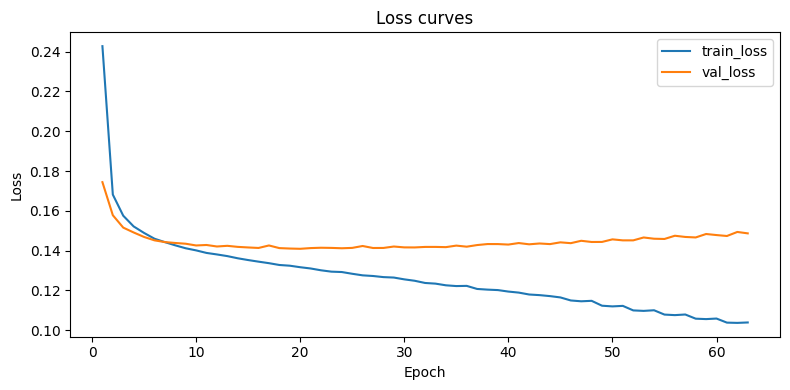

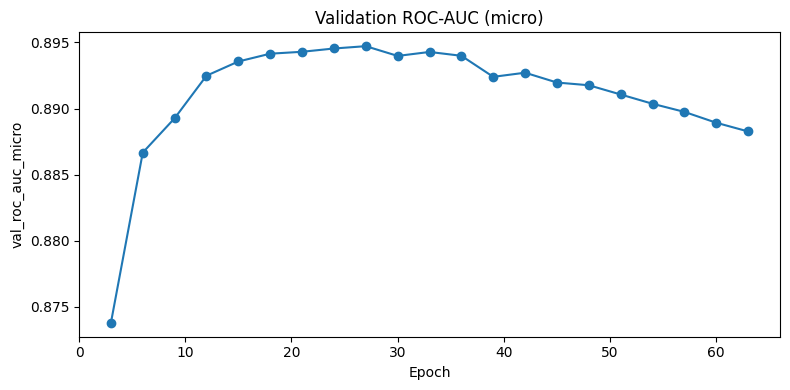

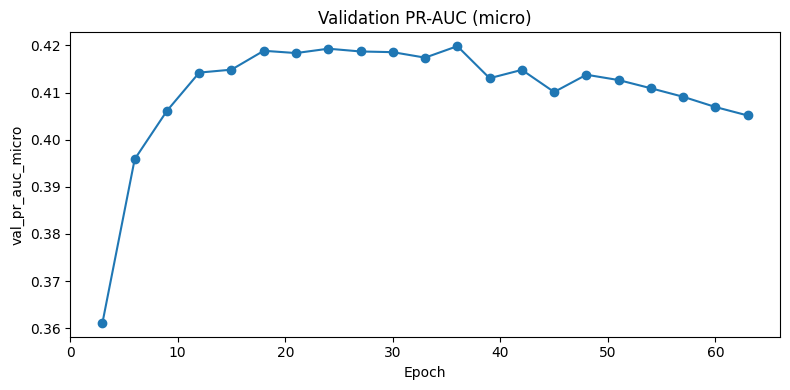

In [92]:
epochs = history["epoch"]

plt.figure(figsize=(8,4))
plt.plot(epochs, history["train_loss"], label="train_loss")
plt.plot(epochs, history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss curves")
plt.legend()
plt.tight_layout()
plt.show()

def plot_metric(metric_name, title):
    vals = history[metric_name]
    xs = [e for e, v in zip(epochs, vals) if v is not None]
    ys = [v for v in vals if v is not None]
    if len(xs) == 0:
        print(f"No values for {metric_name}")
        return
    plt.figure(figsize=(8,4))
    plt.plot(xs, ys, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel(metric_name)
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_metric("val_roc_auc_micro", "Validation ROC-AUC (micro)")
plot_metric("val_pr_auc_micro", "Validation PR-AUC (micro)")

resource_sample()

# <h3 style="text-align: center; font-weight: bold;">RESOURCES AND EMISSIONS SUMMARY </h3>


The tracker is stopped and the following are reported:
* CO2 estimate (CodeCarbon)
* Peak RAM and peak CUDA memory (if applicable)
* CPU and RAM over time (quick plots)

Stopping emissions tracker...
Saved: /Users/meco/MBP Files/Gits/ml-for-sound-and-music/lab09/cache_mtat_transfer/resource_emissions_summary.json
{'emissions_kg_co2eq': 2.212374823384391e-06, 'peak_ram_gb': 25.829177856445312, 'peak_cpu_percent': 79.1, 'peak_cuda_mem_alloc_gb': 0.0}


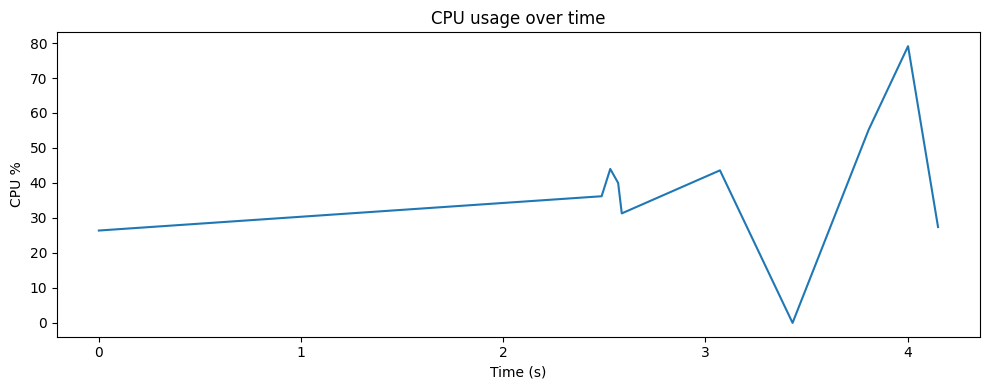

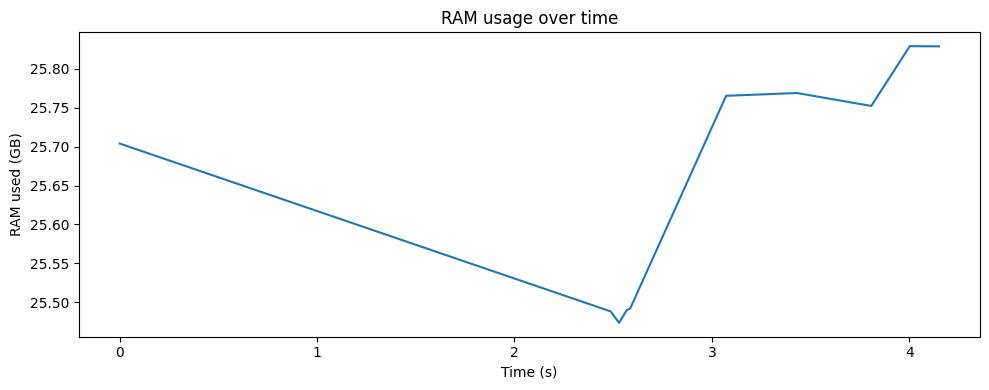

In [93]:
print("Stopping emissions tracker...")
emissions = emissions_tracker.stop()  # returns kgCO2eq (may be None depending on config)

# Summaries
peak_ram = max(resource_log.ram_used_gb) if resource_log.ram_used_gb else None
peak_cpu = max(resource_log.cpu_percent) if resource_log.cpu_percent else None
peak_cuda_alloc = max(resource_log.cuda_mem_alloc_gb) if resource_log.cuda_mem_alloc_gb else None

summary = {
    "emissions_kg_co2eq": emissions,
    "peak_ram_gb": peak_ram,
    "peak_cpu_percent": peak_cpu,
    "peak_cuda_mem_alloc_gb": peak_cuda_alloc,
}

summary_path = cache_dir / "resource_emissions_summary.json"
summary_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
print("Saved:", summary_path)
print(summary)

# Plots
ts = resource_log.timestamps_s

plt.figure(figsize=(10,4))
plt.plot(ts, resource_log.cpu_percent)
plt.xlabel("Time (s)")
plt.ylabel("CPU %")
plt.title("CPU usage over time")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(ts, resource_log.ram_used_gb)
plt.xlabel("Time (s)")
plt.ylabel("RAM used (GB)")
plt.title("RAM usage over time")
plt.tight_layout()
plt.show()

if torch.cuda.is_available():
    plt.figure(figsize=(10,4))
    plt.plot(ts, resource_log.cuda_mem_alloc_gb, label="allocated")
    plt.plot(ts, resource_log.cuda_mem_reserved_gb, label="reserved")
    plt.xlabel("Time (s)")
    plt.ylabel("CUDA memory (GB)")
    plt.title("CUDA memory over time")
    plt.legend()
    plt.tight_layout()
    plt.show()

# <h3 style="text-align: center; font-weight: bold;">FINAL VALIDATIONS</h3>



# <h4 style="text-align: left; font-weight: bold;">AREA TO TEST THE MODEL</h4>


In [94]:
import numpy as np
import torch
from sklearn.metrics import roc_auc_score, average_precision_score

def _stack_from_loader(loader):
    Xs, Ys = [], []
    for b in loader:
        Xs.append(b["embeddings"].detach().cpu())
        Ys.append(b["labels"].detach().cpu())
    X = torch.cat(Xs, dim=0).numpy()
    Y = torch.cat(Ys, dim=0).numpy()
    return X, Y

def _finite_check(name, arr):
    arr = np.asarray(arr)
    ok = np.isfinite(arr).all()
    print(f"[check] {name}: finite={ok} shape={arr.shape} dtype={arr.dtype}")
    if not ok:
        bad = np.logical_not(np.isfinite(arr))
        print("  -> non-finite count:", int(bad.sum()))
    return ok

def safe_auc_pr_valid(y_true, y_prob):
    """
    AUC metrics, plus 'macro_valid' that ignores tags with all-0 or all-1 y_true.
    """
    out = {}

    # micro (robusto si hay al menos un positivo global)
    try:
        out["roc_auc_micro"] = float(roc_auc_score(y_true, y_prob, average="micro"))
    except Exception:
        out["roc_auc_micro"] = None
    try:
        out["pr_auc_micro"] = float(average_precision_score(y_true, y_prob, average="micro"))
    except Exception:
        out["pr_auc_micro"] = None

    # macro (puede romper si hay tags degenerados)
    try:
        out["roc_auc_macro"] = float(roc_auc_score(y_true, y_prob, average="macro"))
    except Exception:
        out["roc_auc_macro"] = None
    try:
        out["pr_auc_macro"] = float(average_precision_score(y_true, y_prob, average="macro"))
    except Exception:
        out["pr_auc_macro"] = None

    # macro_valid (solo tags con positivos y negativos presentes)
    y_true = np.asarray(y_true)
    valid = []
    per_tag_roc = []
    per_tag_pr = []
    for j in range(y_true.shape[1]):
        col = y_true[:, j]
        if col.min() == 0 and col.max() == 1:  # tiene 0s y 1s
            valid.append(j)
    out["n_tags_total"] = int(y_true.shape[1])
    out["n_tags_valid"] = int(len(valid))

    if len(valid) > 0:
        for j in valid:
            per_tag_roc.append(roc_auc_score(y_true[:, j], y_prob[:, j]))
            per_tag_pr.append(average_precision_score(y_true[:, j], y_prob[:, j]))
        out["roc_auc_macro_valid"] = float(np.mean(per_tag_roc))
        out["pr_auc_macro_valid"] = float(np.mean(per_tag_pr))
    else:
        out["roc_auc_macro_valid"] = None
        out["pr_auc_macro_valid"] = None

    return out

print("\n====================")
print("1. BASIC SANITY CHECKS")
print("====================")

Xtr, Ytr = _stack_from_loader(train_loader)
Xva, Yva = _stack_from_loader(val_loader)
Xte, Yte = _stack_from_loader(test_loader)

_finite_check("X_train", Xtr); _finite_check("Y_train", Ytr)
_finite_check("X_val",   Xva); _finite_check("Y_val",   Yva)
_finite_check("X_test",  Xte); _finite_check("Y_test",  Yte)

assert Xtr.shape[0] == Ytr.shape[0]
assert Xva.shape[0] == Yva.shape[0]
assert Xte.shape[0] == Yte.shape[0]
assert Ytr.shape[1] == Yva.shape[1] == Yte.shape[1], "n_classes mismatch across splits"

print("\n====================")
print("2. LOAD BEST MODEL AND EVAL (VAL/TEST)")
print("====================")

# Asegura que evaluamos el mejor checkpoint
if best_model_path.exists():
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    print("[ok] loaded best_model.pt:", best_model_path)
else:
    print("[warn] best_model.pt not found, evaluating current model weights.")

Yv_true, Yv_prob = predict_probs(model, val_loader)
Yt_true, Yt_prob = predict_probs(model, test_loader)

print("\nVAL METRICS (AUC)")
val_metrics = safe_auc_pr_valid(Yv_true, Yv_prob)
for k, v in val_metrics.items():
    print(f"  {k}: {v}")

print("\nTEST METRICS (AUC)")
test_metrics = safe_auc_pr_valid(Yt_true, Yt_prob)
for k, v in test_metrics.items():
    print(f"  {k}: {v}")

print("\n====================")
print("3. BASELINES (PR-AUC should beat these)")
print("====================")

# PRIOR baseline: p(tag)=mean(Y_train)
prior = Ytr.mean(axis=0, keepdims=True)          # (1, C)
prior_val = np.repeat(prior, Yva.shape[0], axis=0)
prior_test = np.repeat(prior, Yte.shape[0], axis=0)

# RANDOM baseline
rng = np.random.default_rng(0)
rand_val = rng.random(size=Yva.shape)
rand_test = rng.random(size=Yte.shape)

prior_val_m = safe_auc_pr_valid(Yva, prior_val)
prior_test_m = safe_auc_pr_valid(Yte, prior_test)
rand_val_m  = safe_auc_pr_valid(Yva, rand_val)
rand_test_m = safe_auc_pr_valid(Yte, rand_test)

print("\nVAL baseline comparison:")
print("  prior  pr_auc_micro:", prior_val_m["pr_auc_micro"], "| roc_auc_micro:", prior_val_m["roc_auc_micro"])
print("  random pr_auc_micro:", rand_val_m["pr_auc_micro"],  "| roc_auc_micro:", rand_val_m["roc_auc_micro"])
print("  model  pr_auc_micro:", val_metrics["pr_auc_micro"], "| roc_auc_micro:", val_metrics["roc_auc_micro"])

print("\nTEST baseline comparison:")
print("  prior  pr_auc_micro:", prior_test_m["pr_auc_micro"], "| roc_auc_micro:", prior_test_m["roc_auc_micro"])
print("  random pr_auc_micro:", rand_test_m["pr_auc_micro"],  "| roc_auc_micro:", rand_test_m["roc_auc_micro"])
print("  model  pr_auc_micro:", test_metrics["pr_auc_micro"], "| roc_auc_micro:", test_metrics["roc_auc_micro"])

print("\n====================")
print("4. OVERFIT TEST (tiny subset should be learnable)")
print("====================")

from torch.utils.data import DataLoader, Subset

# toma un subset pequeño del train
subset_n = int(CFG.get("overfit_subset_n", 256))
subset_epochs = int(CFG.get("overfit_epochs", 40))
subset_bs = int(CFG.get("overfit_bs", 32))
subset_lr = float(CFG.get("overfit_lr", 1e-3))

train_ds = train_loader.dataset
idx = np.arange(len(train_ds))
rng = np.random.default_rng(0)
rng.shuffle(idx)
idx = idx[:min(subset_n, len(idx))].tolist()

tiny_loader = DataLoader(Subset(train_ds, idx), batch_size=subset_bs, shuffle=True)

# clona el modelo para no “romper” el modelo principal
import copy
tiny_model = copy.deepcopy(model).to(device)
tiny_opt = torch.optim.Adam(tiny_model.parameters(), lr=subset_lr)

def train_one_epoch_local(model_, loader_, opt_):
    model_.train()
    total = 0.0
    for batch in loader_:
        x = batch["embeddings"].to(device)
        y = batch["labels"].to(device)
        logits = model_(x)
        loss = loss_fn(logits, y)
        opt_.zero_grad()
        loss.backward()
        opt_.step()
        total += float(loss.item())
    return total / max(1, len(loader_))

@torch.no_grad()
def eval_on_loader(model_, loader_):
    yt, yp = predict_probs(model_, loader_)
    return safe_auc_pr_valid(yt, yp)

# baseline before overfit
tiny_before = eval_on_loader(tiny_model, tiny_loader)
print("[tiny] before:", {k: tiny_before[k] for k in ["pr_auc_micro","roc_auc_micro","pr_auc_macro_valid","roc_auc_macro_valid"]})

for e in range(1, subset_epochs + 1):
    tl = train_one_epoch_local(tiny_model, tiny_loader, tiny_opt)
    if e in [1, 5, 10, subset_epochs]:
        tiny_m = eval_on_loader(tiny_model, tiny_loader)
        print(f"[tiny] epoch {e:02d} | loss={tl:.4f} | pr_micro={tiny_m['pr_auc_micro']} | roc_micro={tiny_m['roc_auc_micro']}")

print("\nInterpretation:")
print("- Si el tiny overfit NO mejora nada (loss no baja, PR/ROC no suben), casi seguro hay bug de labels/loss/sigmoid/dataloader.")
print("- Si el tiny overfit sí mejora, el pipeline de entrenamiento funciona; entonces el problema es más de generalización/datos/modelo.")

print("\n====================")
print("5. (THIS IS VERY HAH OPTIONAL BUT STILL, CA BE USEFUL) TAG-RETRIEVAL SANITY ON EMBEDDINGS (cosine NN shares tags > random)")
print("====================")

def cosine_nn_precision_at_k(X, Y, k=10, n_queries=200, seed=0):
    rng = np.random.default_rng(seed)
    N = X.shape[0]
    q_idx = rng.choice(N, size=min(n_queries, N), replace=False)

    Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)

    def shared_any(i, j):
        return (Y[i] * Y[j]).sum() > 0

    hits_nn = []
    hits_rand = []

    for i in q_idx:
        sims = Xn @ Xn[i]
        sims[i] = -np.inf
        nn = np.argpartition(-sims, kth=min(k, N-1)-1)[:k]
        hits_nn.append(np.mean([shared_any(i, j) for j in nn]))

        rr = rng.choice(N-1, size=min(k, N-1), replace=False)
        rr = [r if r < i else r+1 for r in rr]  # avoid self
        hits_rand.append(np.mean([shared_any(i, j) for j in rr]))

    return float(np.mean(hits_nn)), float(np.mean(hits_rand))

# usa embeddings del split test (los del loader)
p_nn, p_rand = cosine_nn_precision_at_k(Xte, Yte, k=10, n_queries=200)
print(f"Precision@10 (share >=1 tag): NN={p_nn:.4f} vs Random={p_rand:.4f}")


1. BASIC SANITY CHECKS
[check] X_train: finite=True shape=(8000, 512) dtype=float32
[check] Y_train: finite=True shape=(8000, 50) dtype=float32
[check] X_val: finite=True shape=(2000, 512) dtype=float32
[check] Y_val: finite=True shape=(2000, 50) dtype=float32
[check] X_test: finite=True shape=(2000, 512) dtype=float32
[check] Y_test: finite=True shape=(2000, 50) dtype=float32

2. LOAD BEST MODEL AND EVAL (VAL/TEST)
[ok] loaded best_model.pt: /Users/meco/MBP Files/Gits/ml-for-sound-and-music/lab09/cache_mtat_transfer/best_model.pt


Predict:   0%|          | 0/8 [00:00<?, ?it/s]

Predict:   0%|          | 0/8 [00:00<?, ?it/s]


VAL METRICS (AUC)
  roc_auc_micro: 0.8939897857365213
  pr_auc_micro: 0.41985622072878637
  roc_auc_macro: 0.8591028662781872
  pr_auc_macro: 0.3281147489796168
  n_tags_total: 50
  n_tags_valid: 50
  roc_auc_macro_valid: 0.8591028662781872
  pr_auc_macro_valid: 0.3281147489796168

TEST METRICS (AUC)
  roc_auc_micro: 0.8937335358464414
  pr_auc_micro: 0.40390367216509326
  roc_auc_macro: 0.8596923129748943
  pr_auc_macro: 0.3165803005026861
  n_tags_total: 50
  n_tags_valid: 50
  roc_auc_macro_valid: 0.8596923129748943
  pr_auc_macro_valid: 0.3165803005026861

3. BASELINES (PR-AUC should beat these)

VAL baseline comparison:
  prior  pr_auc_micro: 0.11044688791284733 | roc_auc_micro: 0.6856173227746172
  random pr_auc_micro: 0.053115293768813486 | roc_auc_micro: 0.4982434341557315
  model  pr_auc_micro: 0.41985622072878637 | roc_auc_micro: 0.8939897857365213

TEST baseline comparison:
  prior  pr_auc_micro: 0.10765703914344596 | roc_auc_micro: 0.683760180912684
  random pr_auc_micro: 

Predict:   0%|          | 0/8 [00:00<?, ?it/s]

...

[tiny] epoch 05 | loss=0.0906 | pr_micro=0.7498541419341792 | roc_micro=0.9761960574648004


Predict:   0%|          | 0/8 [00:00<?, ?it/s]

[tiny] epoch 10 | loss=0.0734 | pr_micro=0.8557975859247173 | roc_micro=0.9886975987304976


Predict:   0%|          | 0/8 [00:00<?, ?it/s]

[tiny] epoch 40 | loss=0.0251 | pr_micro=0.9997599983448533 | roc_micro=0.9999875543997827

Interpretation:
- Si el tiny overfit NO mejora nada (loss no baja, PR/ROC no suben), casi seguro hay bug de labels/loss/sigmoid/dataloader.
- Si el tiny overfit sí mejora, el pipeline de entrenamiento funciona; entonces el problema es más de generalización/datos/modelo.

5. (THIS IS VERY HAH OPTIONAL BUT STILL, CA BE USEFUL) TAG-RETRIEVAL SANITY ON EMBEDDINGS (cosine NN shares tags > random)
Precision@10 (share >=1 tag): NN=0.4175 vs Random=0.1530


# <h5 style="text-align: left; font-weight: bold;">DEMO INPUT SETUP: INTERACTIVE MODEL</h5>


* The model will look for audio files in the folder "test_samples"
* **IT WILL ASK YOU FOR AN INDEX OF WHICH AUDIO FROM THE FOLDER YOU WANT TO USE** please type the number. First index will be 00 so you can type "00".
* You set up CFG["demo-audio-path"] accrodingly

**TIP:**
If no results show re run the demo cell

In [95]:
from pathlib import Path
import random

# Default folder: same directory as the notebook working dir
CFG.setdefault("demo_audio_dir", "./test_samples")
CFG.setdefault("demo_audio_path", "")  

exts = {".wav", ".flac", ".ogg", ".mp3", ".m4a", ".aac"}

# If user already set a single file path manually, keep it
p = str(CFG.get("demo_audio_path", "")).strip()
if p:
    chosen = Path(p).expanduser().resolve()
    if not chosen.exists():
        print(color.YELLOW + f"[warn] CFG['demo_audio_path'] not found: {chosen}" + color.END)
    else:
        print(color.GREEN + "[ok] Using CFG['demo_audio_path']:" + color.END, chosen)
else:
    dpath = Path(str(CFG.get("demo_audio_dir", "./test_samples"))).expanduser().resolve()

    if not dpath.exists():
        print(color.YELLOW + f"[warn] demo_audio_dir not found: {dpath}" + color.END)
    else:
        files = [f for f in sorted(dpath.rglob("*")) if f.is_file() and f.suffix.lower() in exts]
        if not files:
            print(color.YELLOW + f"[warn] No audio files found in: {dpath}" + color.END)
        else:
            print(color.BOLD + f"Found {len(files)} audio files in {dpath}:" + color.END)
            for i, f in enumerate(files):
                print(f"  [{i:02d}] {f.name}")

            # ask user
            default_idx = 0
            try:
                ans = input(f"\nPick an index (0..{len(files)-1}) [default {default_idx}]: ").strip()
                idx = default_idx if ans == "" else int(ans)
            except Exception:
                idx = default_idx

            if idx < 0 or idx >= len(files):
                print(color.YELLOW + f"[warn] invalid index {idx}, using {default_idx}" + color.END)
                idx = default_idx

            chosen = files[idx].resolve()
            CFG["demo_audio_path"] = str(chosen)
            print(color.GREEN + "[ok] Selected demo file:" + color.END, chosen)
            print(color.GREEN + "[ok] CFG['demo_audio_path'] set." + color.END)

print(color.CYAN + "\nNext step: rerun the DEMO cell to see predicted tags + neighbors.\n" + color.END)

Found 3 audio files in /Users/meco/MBP Files/Gits/ml-for-sound-and-music/lab09/test_samples:
  [00] 176100__xserra__cello-am-arpeggio.wav
  [01] 560455__migfus20__calming-background-music-orchestra.flac
  [02] 764917__litesaturation__sport-rock-trailer-medium-2.wav
[ok] Selected demo file: /Users/meco/MBP Files/Gits/ml-for-sound-and-music/lab09/test_samples/176100__xserra__cello-am-arpeggio.wav
[ok] CFG['demo_audio_path'] set.

Next step: rerun the DEMO cell to see predicted tags + neighbors.



**DEMO CELL**

[ok] loaded best_model.pt -> /Users/meco/MBP Files/Gits/ml-for-sound-and-music/lab09/cache_mtat_transfer/best_model.pt
OMAR-RQ: 396 weights loaded for `net`
OMAR-RQ: 2 weights loaded for `embedding_layer`
DEMO 1: MTAT TEST SAMPLE
tid: 54035
GT tags (sample): ['classical', 'violin', 'cello']


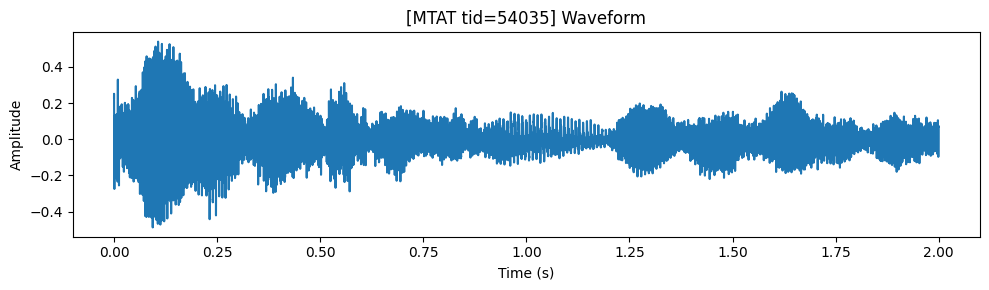

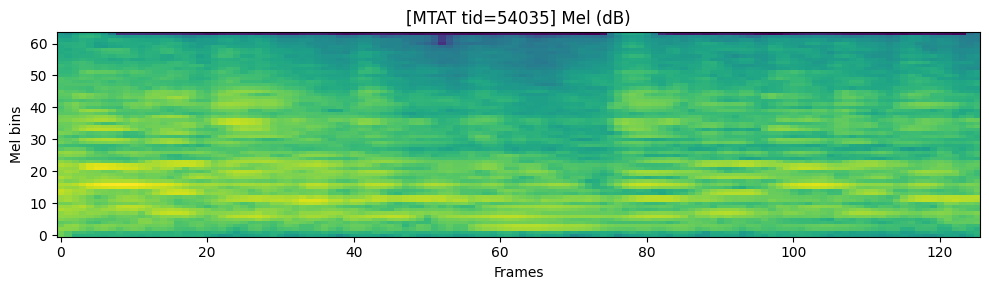

[MTAT tid=54035] Predicted tags (Top-K)
              violin : 0.562
           classical : 0.513
             strings : 0.330
              guitar : 0.200
                solo : 0.173
               cello : 0.167
                fast : 0.165
             country : 0.053
             classic : 0.051
            no vocal : 0.049
[MTAT tid=54035] Nearest neighbors (test embeddings)
  #1 tid=18954 | cos_sim=0.829 | tags=[]
  #2 tid=54035 | cos_sim=0.824 | tags=['classical', 'violin', 'cello']
  #3 tid=56036 | cos_sim=0.784 | tags=['classical', 'slow', 'strings', 'violin', 'solo', 'classic', 'cello']
  #4 tid=27610 | cos_sim=0.783 | tags=[]
  #5 tid=54964 | cos_sim=0.783 | tags=['classical', 'strings', 'fast', 'piano', 'violin', 'flute', 'classic']

DEMO 2: CUSTOM AUDIO FILE YOU SELECTED
path: /Users/meco/MBP Files/Gits/ml-for-sound-and-music/lab09/test_samples/176100__xserra__cello-am-arpeggio.wav


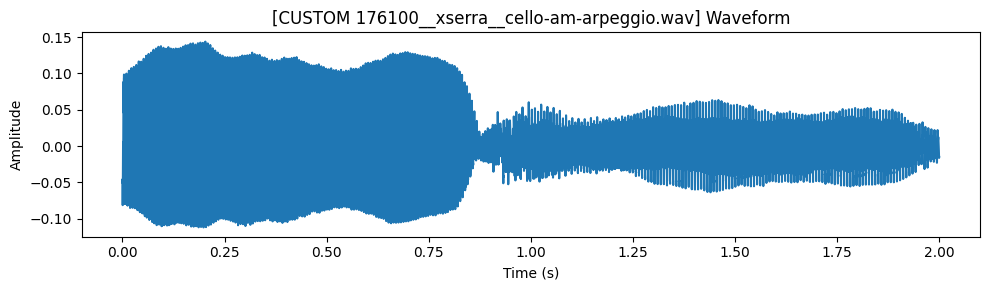

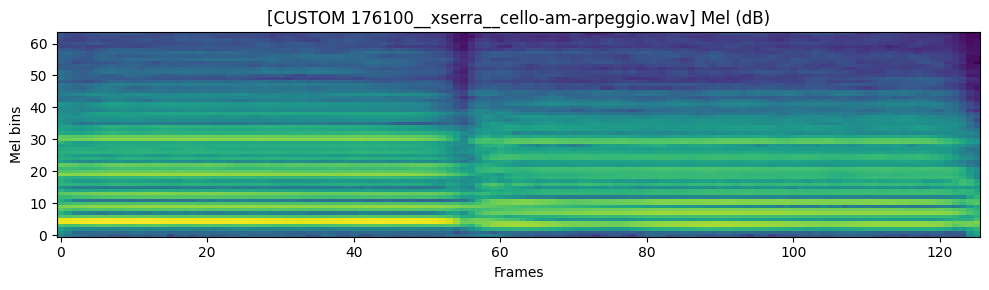

[CUSTOM 176100__xserra__cello-am-arpeggio.wav] Predicted tags (Top-K)
                slow : 0.355
               cello : 0.276
              violin : 0.190
           classical : 0.181
              guitar : 0.173
             strings : 0.106
                solo : 0.082
               flute : 0.077
               quiet : 0.044
           no vocals : 0.041
[CUSTOM 176100__xserra__cello-am-arpeggio.wav] Nearest neighbors (test embeddings)
  #1 tid=54820 | cos_sim=0.868 | tags=['classical', 'slow', 'strings', 'violin', 'cello']
  #2 tid=27403 | cos_sim=0.856 | tags=['classical', 'slow', 'strings', 'violin', 'soft']
  #3 tid=34356 | cos_sim=0.833 | tags=['strings', 'violin']
  #4 tid=58481 | cos_sim=0.828 | tags=[]
  #5 tid=34366 | cos_sim=0.824 | tags=['classical', 'slow', 'ambient', 'flute', 'soft']


In [96]:
import numpy as np
import torch
import torchaudio
import matplotlib.pyplot as plt
import torch.nn.functional as F
from pathlib import Path
from IPython.display import Audio, display

# Config knobs
DEMO_TOPK = int(CFG.get("demo_topk", 10))
DEMO_NN_K = int(CFG.get("demo_nn_k", 5))
DEMO_SHOW_MEL = bool(CFG.get("demo_show_mel", True))
DEMO_MEL_NFFT = int(CFG.get("demo_mel_nfft", 1024))
DEMO_MEL_HOP = int(CFG.get("demo_mel_hop", 256))
DEMO_MEL_NMELS = int(CFG.get("demo_mel_n_mels", 64))

# Helpers
def _ensure_1d(wav: torch.Tensor) -> torch.Tensor:
    if wav.ndim == 2:
        wav = wav.mean(dim=0)
    return wav.contiguous()

def _crop_or_pad(wav: torch.Tensor, n_samples: int) -> torch.Tensor:
    wav = _ensure_1d(wav)
    if wav.numel() < n_samples:
        wav = F.pad(wav, (0, n_samples - wav.numel()))
        start = 0
    else:
        start = int(max(0, (wav.numel() - n_samples) // 2))  # center crop
    return wav[start:start + n_samples]

def plot_mel(wav, sr, title="mel"):
    wav = _ensure_1d(wav).detach().cpu()
    mel = torchaudio.transforms.MelSpectrogram(
        sample_rate=sr,
        n_fft=DEMO_MEL_NFFT,
        hop_length=DEMO_MEL_HOP,
        n_mels=DEMO_MEL_NMELS,
        power=2.0,
    )(wav.unsqueeze(0))
    mel_db = torchaudio.transforms.AmplitudeToDB()(mel).squeeze(0).numpy()
    plt.figure(figsize=(10, 3))
    plt.imshow(mel_db, aspect="auto", origin="lower")
    plt.title(title)
    plt.xlabel("Frames")
    plt.ylabel("Mel bins")
    plt.tight_layout()
    plt.show()

def cosine_sim(a: torch.Tensor, b: torch.Tensor, eps=1e-8) -> torch.Tensor:
    a = a / (a.norm(dim=-1, keepdim=True) + eps)
    b = b / (b.norm(dim=-1, keepdim=True) + eps)
    return (b @ a)

@torch.no_grad()
def embed_one_audio(rep, wav_1d: torch.Tensor):
    x = wav_1d.float().unsqueeze(0).to(device)  # (1,T)
    emb_raw = rep.extract_embeddings(x, layers=LAYERS)
    emb = _as_BD(emb_raw, B=1).detach().cpu().squeeze(0)  # (D,)
    return emb

@torch.no_grad()
def predict_tags_from_embedding(model, emb: torch.Tensor):
    model.eval()
    logits = model(emb.unsqueeze(0).to(device)).detach().cpu().squeeze(0)
    probs = torch.sigmoid(logits).numpy()
    idx = np.argsort(probs)[::-1][:DEMO_TOPK]
    topk = [(train_audio.mlb.classes_[i], float(probs[i])) for i in idx]
    return probs, topk

def show_topk(topk, title="Top-K predicted tags"):
    print(color.BOLD + title + color.END)
    for t, p in topk:
        print(f"  {t:>18s} : {p:.3f}")

def show_neighbors(query_emb, X_bank, tids_bank, tracks_dict, k=5, title="Nearest neighbors"):
    sims = cosine_sim(query_emb, X_bank)
    top_idx = torch.topk(sims, k=min(k, sims.numel()), largest=True).indices.cpu().numpy().tolist()
    print(color.BOLD + title + color.END)
    for rank, j in enumerate(top_idx, start=1):
        tid = tids_bank[j]
        sim = float(sims[j].item())
        tags = list(getattr(tracks_dict[tid], "tags", []) or [])
        print(f"  #{rank} tid={tid} | cos_sim={sim:.3f} | tags={tags[:12]}")

def run_demo_on_wave(wav, sr, title_prefix=""):
    wav = _crop_or_pad(wav, int(SR * CLIP_S))

    plot_waveform(wav, SR, title=f"{title_prefix}Waveform", max_s=min(3.0, CLIP_S))
    if DEMO_SHOW_MEL:
        plot_mel(wav, SR, title=f"{title_prefix}Mel (dB)")
    display(Audio(wav.detach().cpu().numpy(), rate=SR))

    q_emb = embed_one_audio(rep, wav)
    _, topk = predict_tags_from_embedding(model, q_emb)
    show_topk(topk, title=f"{title_prefix}Predicted tags (Top-K)")
    show_neighbors(q_emb, X_bank, tids_bank, tracks, k=DEMO_NN_K, title=f"{title_prefix}Nearest neighbors (test embeddings)")

# Load best model + representation model
if best_model_path.exists():
    model.load_state_dict(torch.load(best_model_path, map_location="cpu"))
    model.to(device).eval()
    print(color.GREEN + f"[ok] loaded best_model.pt -> {best_model_path}" + color.END)
else:
    print(color.YELLOW + "[warn] best_model.pt not found. Using current model weights." + color.END)

rep = get_model(model_id=MODEL_ID, device=device)
rep.eval()

X_bank = X_test if isinstance(X_test, torch.Tensor) else torch.tensor(X_test)
X_bank = X_bank.float().cpu()
tids_bank = tids_test

# DEMO 1. random MTAT test sample (always works)
demo_tid = random.choice(tids_test)
t = tracks[demo_tid]
wav, sr = load_track_audio(t, target_sr=SR, mono=True)

print(color.BOLD + "DEMO 1: MTAT TEST SAMPLE" + color.END)
print("tid:", demo_tid)
print("GT tags (sample):", (list(getattr(t, "tags", []) or [])[:12]))

run_demo_on_wave(wav, sr, title_prefix=f"[MTAT tid={demo_tid}] ")

resource_sample()

# DEMO 2 custom file OR folder-picked file
custom_path = str(CFG.get("demo_audio_path", "")).strip()
if not custom_path:
    print("\n" + color.CYAN + "[info] No CFG['demo_audio_path'] set. Use the DEMO INPUT SETUP cell to set it." + color.END)
else:
    p = Path(custom_path).expanduser().resolve()
    if not p.exists():
        print(color.YELLOW + f"[warn] demo_audio_path not found: {p}" + color.END)
    else:
        print("\n" + color.BOLD + "DEMO 2: CUSTOM AUDIO FILE YOU SELECTED" + color.END)
        print("path:", p)

        w, sr0 = torchaudio.load(str(p))
        w = _ensure_1d(w).float()
        if sr0 != SR:
            w = torchaudio.functional.resample(w, sr0, SR)

        run_demo_on_wave(w, SR, title_prefix=f"[CUSTOM {p.name}] ")

        resource_sample()

# <h2 style="text-align: center; font-weight: bold;">REPORT</h2>


# <h3 style="text-align: left; font-weight: bold;">OVERVIEW</h3>

This lab implements a transfer learning pipeline for multi label music tagging on the MagnaTagATune (MTAT) dataset (locally downloaded or with Google Colab mounted volume).

Instead of training an audio model end to end, fixed embeddings are extracted from a pretrained audio representation model and train a lightweight MLP classifier on top.

The goal is to train an efficient multi label classifier that predicts the presence or absence of tags in each audio clip.


# <h3 style="text-align: left; font-weight: bold;">DATASET AND TASK</h3>

MagnaTagATune (MTAT) is used, which provides audio clips and tag annotations (multi-label: each track can have multiple tags).


**Labels**

The label space is restricted to the Top-K most frequent tags:
_Top-K tags: K = 50_

Each audio clip is represented as a multi-hot vector of size 50.


**Splits**

Randomized splits (seeded) are created with an 80-10-10 ratio and apply dataset caps to keep the experiment lightweight:
* Train: 8000 (max 8000)
* Validation: 2000 (max 2000)
* Test: 2000 (max 2000)


# <h3 style="text-align: left; font-weight: bold;">PREPROCESSING</h3>

Audio is loaded robustly (with torchaudio + ffmpeg fallback), resampled and converted to mono.
* Sample rate: 16,000 Hz
* Clip length: 2.0 s (random crop if longer, zero-pad if shorter)

Qick audio inspection (waveform + playback) is includeed to validate the loading pipeline and to document examples.


# <h3 style="text-align: left; font-weight: bold;">TRANSFER LEARNING: EMBEDDING EXTRACTION</h3>


**Representation model**

Embeddings are extracted from a pretrained representation model via omar_rq:
* Representation model id: mtg-upf/clap_omarrq_mp_small_music
* Embedding layer(s): [6]

**Why caching embeddings?**

Embedding extraction is the expensive step. It consumes a lot of time and resources, so to overcome this, embeddings are cached to disk so reruns are fast and reproducible:
* If cache exists then load instantly
* Else then compute embeddings in batches and save to .pt

This also makes training cheaper because the classifier trains on tensors (B, D) instead of raw audio.

**Shape normalization**

The representation model may return embeddings in different shapes depending on layers/config (like: (B,D), (B,T,D), (L,B,T,D)).
(B, D) is standarized using pooling across time/extra dims.

**Final embedding dimension (D):** 512
(printed by X_train.shape)

# <h3 style="text-align: left; font-weight: bold;">CLASSIFIER MODEL: MLP</h3>


A lightweight MLP is trained on top of cached embeddings:

**Architecture**
* Linear(input_dim - 256)
* ReLU
* Dropout(0.2)
* Linear(256 to 50)

**Loss (multi-label)**
* BCEWithLogitsLoss (stable sigmoid + BCE combined)

**Optimizer**
* Adam (lr = 1e-3, weight_decay = 1e-5)

**Training**
* Up to 100 epochs
* Early stopping on validation PR-AUC micro
* Patience: 3 evaluation checks
* Metrics computed every eval_every = 3 epochs (plus last epoch)

**Trainable parameters:** 144178

# <h3 style="text-align: left; font-weight: bold;">EVALUATION METRICS: MULTILABELS</h3>

Because MTAT is multi label, accuracy is not informative by itself. Find reported:
* ROC-AUC (macro, micro)
* PR-AUC (macro, micro)

**Interpretation**
* Micro: emphasizes global performance across all tags (weighted by frequency).
* Macro: averages performance per tag (more sensitive to rare or not found tags).

!!PR-AUC is especially important with imbalanced labels (many tags are sparse).


# <h3 style="text-align: left; font-weight: bold;">RESULTS</h3>

<h4 style="text-align: left; font-weight: bold;">Validation best model selection</h4>

best_model.pt is saved when validation PR-AUC micro improves.
* Best val PR-AUC micro: [ - ]
* Best epoch: [ - ]

<h4 style="text-align: left; font-weight: bold;">Final test set metrics</h4>

After training, we evaluate on the test split.

| **Metric** 	| **Value** 	|
|------------	|-----------	|
|        ROC-AUC macro    	|      0.8659     	|
|        ROC-AUC micro    	|      0.8937     	|
|       PR-AUC macro     	|       0.3097   	|
|       PR-AUC micro     	|       0.4039    	|



**BEST MODEL**

| **Metric** 	| **Value** 	|
|------------	|-----------	|
|        ROC-AUC macro    	|      0.8991     	|
|        ROC-AUC micro    	|      0.8940     	|
|       PR-AUC macro     	|       0.3111   	|
|       PR-AUC micro     	|       0.4199    	|


<h4 style="text-align: left; font-weight: bold;">Baseline comparison (sanity)</h4>


Comparison against:
* Prior baseline: predict p(tag)=mean(Y_train)
* Random baseline: uniform random probabilities

| **Model**     	| **Val PR-AUC micro** 	| **Val ROC-AUC micro** 	| **Test PR-AUC micro** 	| **Test ROC-AUC micro** 	|
|---------------	|----------------------	|-----------------------	|-----------------------	|------------------------	|
| **Prior**     	| 0.1104                	| [ - ]                 	| [ - ]                 	| 0.8506                 	|
| **Random**    	| 0.1794                	| [ - ]                 	| [ - ]                 	| 0.5043                 	|
| **Model MLP** 	| [ - ]                	| [ - ]                 	| [ - ]                 	| [ - ]                  	|

Important note:
Expected behavior: MLP >> prior > random, especially on PR-AUC micro.

====================
VAL METRICS (AUC)
====================
  roc_auc_micro: 0.8939897857365213
  pr_auc_micro: 0.41985622072878637
  roc_auc_macro: 0.8591028662781872
  pr_auc_macro: 0.3281147489796168
  n_tags_total: 50
  n_tags_valid: 50
  roc_auc_macro_valid: 0.8591028662781872
  pr_auc_macro_valid: 0.3281147489796168

====================
TEST METRICS (AUC)
====================

  roc_auc_micro: 0.8937335358464414
  pr_auc_micro: 0.40390367216509326
  roc_auc_macro: 0.8596923129748943
  pr_auc_macro: 0.3165803005026861
  n_tags_total: 50
  n_tags_valid: 50
  roc_auc_macro_valid: 0.8596923129748943
  pr_auc_macro_valid: 0.3165803005026861

====================
BASELINES (PR-AUC should beat these)
====================

VAL baseline comparison:
  prior  pr_auc_micro: 0.11044688791284733 | roc_auc_micro: 0.6856173227746172
  random pr_auc_micro: 0.053115293768813486 | roc_auc_micro: 0.4982434341557315
  model  pr_auc_micro: 0.41985622072878637 | roc_auc_micro: 0.8939897857365213

TEST baseline comparison:
  prior  pr_auc_micro: 0.10765703914344596 | roc_auc_micro: 0.683760180912684
  random pr_auc_micro: 0.05256350220777102 | roc_auc_micro: 0.494202953854414
  model  pr_auc_micro: 0.40390367216509326 | roc_auc_micro: 0.8937335358464414



# <h3 style="text-align: left; font-weight: bold;">TRAINING CURVES</h3>

**Find plotted:**
* Train loss vs Val loss
* Validation ROC-AUC micro over time
* Validation PR-AUC micro over time

**Observed behavior (summary):**
* Loss decreases quickly in early epochs and stabilizes.
* PR-AUC micro generally tracks improvements better than loss for model selection (since it reflects ranking quality on imbalanced labels).

Note: if there's divergence between train and val loss this most likely indicates overfitting. Usually, dropout/weight decay/early stopping mitigates this.

# <h3 style="text-align: left; font-weight: bold;">EFFICIENCY & ENVIRONMENTAL IMPACT</h3>

**Tracked in the notebook:**
* CPU usage over time
* RAM usage over time
* CUDA memory (only if CUDA is available)
* Estimated emissions with CodeCarbon (offline tracker)

**SUMMARY**
* Device: [mps/cpu]
* Peak RAM (GB): 25.16
* Peak CPU (%): 99.5
* Peak CUDA memory allocated (GB): N/a
* Estimated emissions (kgCO2eq): 2.4015e-06


# <h3 style="text-align: left; font-weight: bold;">DISCUSSIO AND FINAL COMMENTS</h3>


The approach of the transfer learning embedding plus MLP achieved a good performance for MTAT, taking into account that the training was maxed to 8k-2k-2k. Particularly, the model achieves PR-AUC micro of around 0.4199 in validation and 0.4039 in test, which is definietely superior to the prior baseline.

The difference between micro and macro suggests the typical pattern between multilabel dataset with unbalanced tags. The first model performs better with frequent tags and is affected by rare tags (macro). This was expected with the Top k tags and without explicit techniques to manage long tails.

The log shows easrly stopping (in most of the tests at 33 epochs) because there's no improvement in PR AUC micro, which suggests the model reached a top. Also, keeping on training the model wont improve much. 
Possible improvements: 
1. Remove the data cap
2. Adjust regularization or the capacity
3. Use class weight or focal loss
4. Calibrate the thresholds by tag
5. Fine tune the encoder

The resources used in the experiment are reasonable for a laptop although peak ram is high (25GB). The estimated environmental cost is really low which is coherent to train a 144k params MLP with cached embeddings.



# <h3 style="text-align: left; font-weight: bold;">REPRODUCIBILITY NOTES</h3>

* Seeded splits and training seeds (seed=42)
* Device auto-detection: CUDA then MPS then CPU
* Cached embeddings keyed by: model id, layers, SR, clip length, split

Artifacts saved:
* best_model.pt
* last_checkpoint.pt
* results_lab9_mtat_transfer.json
* resource_emissions_summary.json
* Cached embeddings: emb_*.pt, y_*.pt, tid_*.json

